## AOUT Analysis



In [19]:
from datetime import datetime

import pandas as pd
import numpy as np
import csv
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm

In [12]:
cosumer_tickers = ["AOUT", "VSTO", "CLAR", "ESCA", "FNKO", "RCKY", "JOUT", "CWH"]
dfs = []
for ticker in cosumer_tickers:
    df_tmp = yf.Ticker(ticker)
    # Download historical price data
    historical_data = df_tmp.history(period="max", interval="1d")
    historical_data['ticker'] = ticker
    # Display the first few rows
    dfs.append(historical_data)

dfs[0].head()



$VSTO: possibly delisted; no timezone found


,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker
Date,,,,,,,,
2020-08-21 00:00:00-04:00,18.180000,18.180,15.500000,15.500000,2100,0.0,0.0,AOUT
2020-08-24 00:00:00-04:00,19.959999,30.010,17.350000,19.400000,106900,0.0,0.0,AOUT
2020-08-25 00:00:00-04:00,16.150000,19.275,14.570000,17.780001,1444400,0.0,0.0,AOUT
2020-08-26 00:00:00-04:00,18.219000,19.298,17.103001,18.930000,661600,0.0,0.0,AOUT
2020-08-27 00:00:00-04:00,19.430000,19.475,17.400000,17.940001,425700,0.0,0.0,AOUT


In [13]:
# append data
df = pd.concat(dfs)
df[df["Stock Splits"] > 0]

/var/folders/j5/d8d1mkwd55q6sz79ygcfg1rr0000gn/T/ipykernel_40216/308116490.py:2: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df = pd.concat(dfs)


,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,Adj Close
Date,,,,,,,,,
2020-08-07 00:00:00-04:00,11.885663,12.442213,11.715868,12.347883,167800.0,0.0,1.002,CLAR,NaN
1994-03-07 00:00:00-05:00,0.712883,0.712883,0.712883,0.712883,600.0,0.0,1.150,ESCA,NaN
2002-04-01 00:00:00-05:00,6.248359,6.498494,5.327864,6.328402,64400.0,0.0,3.000,ESCA,NaN
2004-05-26 00:00:00-04:00,8.109392,9.231920,8.109392,9.080908,21900.0,0.0,2.000,ESCA,NaN


In [14]:
AOUT = df[df["ticker"] == "AOUT"]
AOUT.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,Adj Close
Date,,,,,,,,,
2020-08-21 00:00:00-04:00,18.180000,18.180,15.500000,15.500000,2100.0,0.0,0.0,AOUT,NaN
2020-08-24 00:00:00-04:00,19.959999,30.010,17.350000,19.400000,106900.0,0.0,0.0,AOUT,NaN
2020-08-25 00:00:00-04:00,16.150000,19.275,14.570000,17.780001,1444400.0,0.0,0.0,AOUT,NaN
2020-08-26 00:00:00-04:00,18.219000,19.298,17.103001,18.930000,661600.0,0.0,0.0,AOUT,NaN
2020-08-27 00:00:00-04:00,19.430000,19.475,17.400000,17.940001,425700.0,0.0,0.0,AOUT,NaN


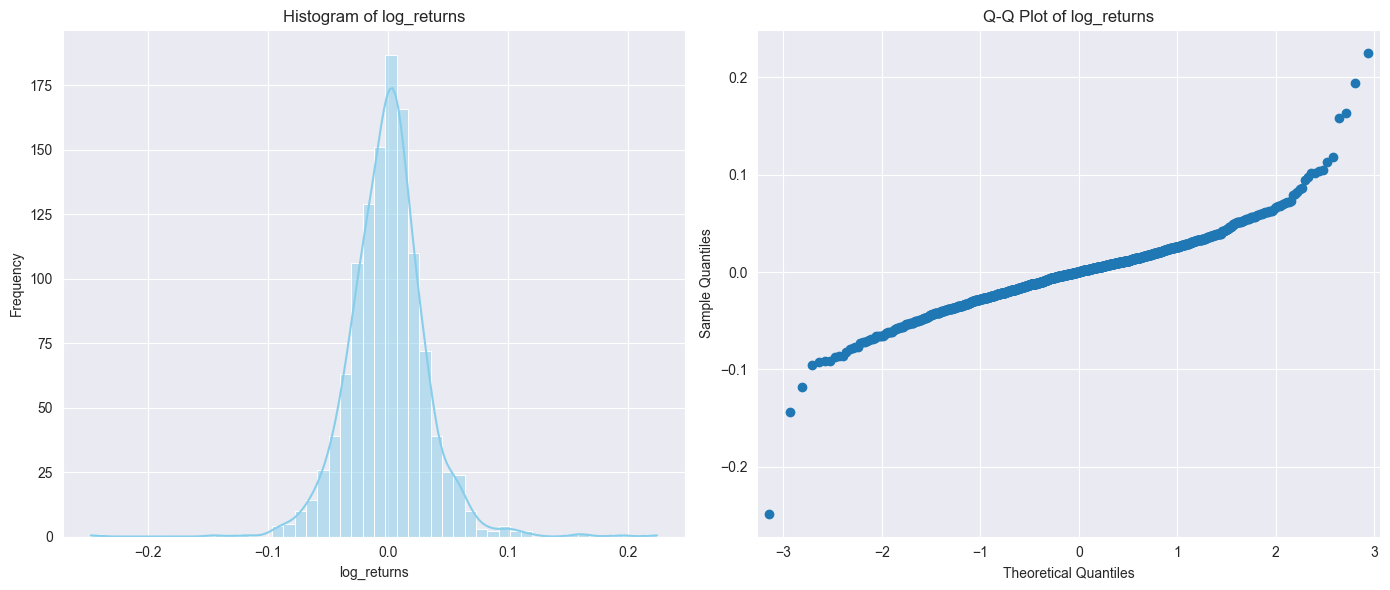

In [18]:
# Calculate the log returns
# AOUT["log_returns"] = np.log(AOUT["Close"]) - np.log(AOUT["Close"].shift(1))
# AOUT["log_returns2"] = np.log(AOUT["Close"] / AOUT["Close"].shift(1))
# plot the distribution of the log returns


# Histogram of log returns
def plot_distribution(df, column: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.histplot(df, x=column, bins=50, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram of {column}')
    axes[0].set_xlabel(f'{column}')
    axes[0].set_ylabel('Frequency')

    # Q-Q plot
    sm.qqplot(df[column], line='s', ax=axes[1])
    axes[1].set_title(f'Q-Q Plot of {column}')

    plt.tight_layout()
    plt.show()


plot_distribution(df=AOUT, column="log_returns")

In [20]:
# Create the csv of the earning report dates
# Define the earnings data
earnings_data = [
    ["Quarter", "Earnings Call Date", "Time (ET)", "Notes"],
    ["Q2 FY2025", "2024-12-05 00:00:00-04:00", "After Market Close", 0.34],
    ["Q1 FY2025", "2024-09-05 00:00:00-04:00", "After Market Close", -0.01],
    ["Q4 FY2024", "2024-06-27 00:00:00-04:00", "After Market Close", -0.08],
    ["Q3 FY2024", "2024-03-07 00:00:00-04:00", "After Market Close", -0.01],
    ["Q2 FY2024", "2023-11-30 00:00:00-04:00", "After Market Close", 0.19],
    ["Q1 FY2024", "2023-09-07 00:00:00-04:00", "After Market Close", -0.06],
    ["Q4 FY2023", "2023-06-28 00:00:00-04:00", "After Market Close", -0.03],
    ["Q3 FY2023", "2023-03-09 00:00:00-04:00", "After Market Close", -0.09],
    ["Q2 FY2023", "2022-12-01 00:00:00-04:00", "After Market Close", 0.03],
    ["Q1 FY2023", "2022-09-08 00:00:00-04:00", "After Market Close", 0.01],
    ["Q4 FY2022", "2022-07-14 00:00:00-04:00", "After Market Close", 0.01],
    ["Q3 FY2022", "2022-03-10 00:00:00-04:00", "After Market Close", 0.03],
    ["Q2 FY2022", "2021-12-09 00:00:00-04:00", "After Market Close", 0.58],
    ["Q1 FY2022", "2021-09-09 00:00:00-04:00", "After Market Close", 0.48],
    ["Q4 FY2021", "2021-07-15 00:00:00-04:00", "After Market Close", 0.13],
    ["Q3 FY2021", "2021-03-17 00:00:00-04:00", "After Market Close", 0.82],
    ["Q2 FY2021", "2020-12-15 00:00:00-04:00", "After Market Close", 0.77],
]

# Write the data to a CSV file
with open("AOUT/AOUT_Earnings_Calls.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(earnings_data)

print("CSV file 'AOUT_Earnings_Calls.csv' has been created.")

CSV file 'AOUT_Earnings_Calls.csv' has been created.


In [22]:
# load the data into a dataframe
df_earnings = pd.read_csv("AOUT/AOUT_Earnings_Calls.csv")
df_earnings.head()

,Quarter,Earnings Call Date,Time (ET),Notes
0,Q2 FY2025,2024-12-05 00:00:00-04:00,After Market Close,0.34
1,Q1 FY2025,2024-09-05 00:00:00-04:00,After Market Close,-0.01
2,Q4 FY2024,2024-06-27 00:00:00-04:00,After Market Close,-0.08
3,Q3 FY2024,2024-03-07 00:00:00-04:00,After Market Close,-0.01
4,Q2 FY2024,2023-11-30 00:00:00-04:00,After Market Close,0.19


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, '2020-12-15 00:00:00-04:00'),
  Text(1, 0, '2021-03-17 00:00:00-04:00'),
  Text(2, 0, '2021-07-15 00:00:00-04:00'),
  Text(3, 0, '2021-09-09 00:00:00-04:00'),
  Text(4, 0, '2021-12-09 00:00:00-04:00'),
  Text(5, 0, '2022-03-10 00:00:00-04:00'),
  Text(6, 0, '2022-07-14 00:00:00-04:00'),
  Text(7, 0, '2022-09-08 00:00:00-04:00'),
  Text(8, 0, '2022-12-01 00:00:00-04:00'),
  Text(9, 0, '2023-03-09 00:00:00-04:00'),
  Text(10, 0, '2023-06-28 00:00:00-04:00'),
  Text(11, 0, '2023-09-07 00:00:00-04:00'),
  Text(12, 0, '2023-11-30 00:00:00-04:00'),
  Text(13, 0, '2024-03-07 00:00:00-04:00'),
  Text(14, 0, '2024-06-27 00:00:00-04:00'),
  Text(15, 0, '2024-09-05 00:00:00-04:00'),
  Text(16, 0, '2024-12-05 00:00:00-04:00')])

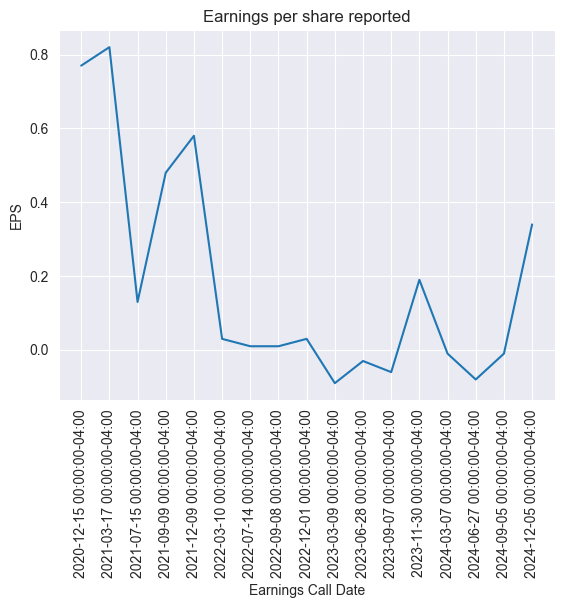

In [58]:
# plot the earnings pershare
sns.lineplot(df_earnings, x="Earnings Call Date", y="Notes").set_title("Earnings per share reported")
plt.xlabel("Earnings Call Date")
plt.ylabel("EPS")
plt.xticks(rotation=90)

In [55]:
# calcualte the proportion of positive returns between each earnings call
# AOUT["Regime"] = AOUT["log_returns"].apply(lambda x: 0 if x <= 0 else 1)

# def get_regime_proportion(df_samp: pd.DataFrame, start_date, end_date) -> float:
#     # filter the data
#     try:
#         df_tmp = df_samp[(df_samp.index >= start_date) & (df_samp.index <= end_date)]["Regime"].value_counts()
#         tmp_sum = df_samp[(df_samp.index >= start_date) & (df_samp.index <= end_date)]["Regime"].value_counts().sum()
#         df_tmp = df_tmp / tmp_sum
#     except Exception as e:
#         return np.nan
#     if df_tmp.shape[0] == 2:
#         return float(df_tmp[df_tmp.index == 1].values[0])
#     else:
#         if df_tmp.index == 1:
#             return float(df_tmp.values[0])
#         else:
#             return 1 - float(df_tmp.values[0])
proportion_vals = []
counter = 0
for earnings_date in df_earnings["Earnings Call Date"]:
    if counter == 0:
        previous_date = earnings_date
        proportion_vals.append(np.nan)
        counter += 1
        continue
    else:
        # filter the AOUT data between previous_date and earnings_date
        count_df = AOUT[(AOUT.index >= previous_date) & (AOUT.index < earnings_date)]["Regime"].value_counts()
        sum_df = count_df.sum()
        prop_val_df = count_df / sum_df
        print(f"for date between {previous_date} and {earnings_date}: {prop_val_df}")
        if prop_val_df.shape[0] == 2:
            prop_val = float(prop_val_df[prop_val_df.index == 1].values[0])
        else:
            if prop_val_df.index[0] == 1:
                prop_val = float(prop_val_df.values[0])
            else:
                prop_val = 1 - float(prop_val_df.values[0])
        proportion_vals.append(prop_val)
        previous_date = earnings_date
        counter += 1


# AOUT["vol_schock"] = AOUT["log_returns"].apply(lambda x: 1 if x >= 0.05 else 0)
# AOUT["vol_schock_neg"] = AOUT["log_returns"].apply(lambda x: 1 if x <= -0.05 else 0)

neg_shocks = []
pos_shocks = []
counter = 0
for earnings_date in df_earnings["Earnings Call Date"]:
    if counter == 0:
        previous_date = earnings_date
        neg_shocks.append(np.nan)
        pos_shocks.append(np.nan)
        counter += 1
        continue
    else:
        pos_val = AOUT[(AOUT.index >= previous_date) & (AOUT.index < earnings_date)]["vol_schock"].sum()
        neg_val = AOUT[(AOUT.index >= previous_date) & (AOUT.index < earnings_date)]["vol_schock_neg"].sum()
        neg_shocks.append(neg_val)
        pos_shocks.append(pos_val)
        previous_date = earnings_date
        counter += 1

# df_earnings["Regime"] = proportion_vals
df_earnings["neg_shocks"] = neg_shocks
df_earnings["pos_shocks"] = pos_shocks
df_earnings
# merge the closing price

for date between 2020-12-15 00:00:00-04:00 and 2021-03-17 00:00:00-04:00: Regime
1    0.5
0    0.5
Name: count, dtype: float64
for date between 2021-03-17 00:00:00-04:00 and 2021-07-15 00:00:00-04:00: Regime
1    0.542169
0    0.457831
Name: count, dtype: float64
for date between 2021-07-15 00:00:00-04:00 and 2021-09-09 00:00:00-04:00: Regime
1    0.589744
0    0.410256
Name: count, dtype: float64
for date between 2021-09-09 00:00:00-04:00 and 2021-12-09 00:00:00-04:00: Regime
0    0.546875
1    0.453125
Name: count, dtype: float64
for date between 2021-12-09 00:00:00-04:00 and 2022-03-10 00:00:00-04:00: Regime
1    0.532258
0    0.467742
Name: count, dtype: float64
for date between 2022-03-10 00:00:00-04:00 and 2022-07-14 00:00:00-04:00: Regime
0    0.581395
1    0.418605
Name: count, dtype: float64
for date between 2022-07-14 00:00:00-04:00 and 2022-09-08 00:00:00-04:00: Regime
0    0.641026
1    0.358974
Name: count, dtype: float64
for date between 2022-09-08 00:00:00-04:00 and 2022

,Quarter,Earnings Call Date,Time (ET),Notes,Regime,neg_shocks,pos_shocks
16,Q2 FY2021,2020-12-15 00:00:00-04:00,After Market Close,0.77,NaN,NaN,NaN
15,Q3 FY2021,2021-03-17 00:00:00-04:00,After Market Close,0.82,0.495094,0.0,7.0
14,Q4 FY2021,2021-07-15 00:00:00-04:00,After Market Close,0.13,0.494806,2.0,6.0
13,Q1 FY2022,2021-09-09 00:00:00-04:00,After Market Close,0.48,0.490779,4.0,1.0
12,Q2 FY2022,2021-12-09 00:00:00-04:00,After Market Close,0.58,0.486660,2.0,0.0
11,Q3 FY2022,2022-03-10 00:00:00-04:00,After Market Close,0.03,0.489118,3.0,2.0
10,Q4 FY2022,2022-07-14 00:00:00-04:00,After Market Close,0.01,0.485820,7.0,4.0
9,Q1 FY2023,2022-09-08 00:00:00-04:00,After Market Close,0.01,0.493793,3.0,3.0
8,Q2 FY2023,2022-12-01 00:00:00-04:00,After Market Close,0.03,0.501458,6.0,4.0
7,Q3 FY2023,2023-03-09 00:00:00-04:00,After Market Close,-0.09,0.488038,2.0,1.0


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, '2020-12-15 00:00:00-04:00'),
  Text(1, 0, '2021-03-17 00:00:00-04:00'),
  Text(2, 0, '2021-07-15 00:00:00-04:00'),
  Text(3, 0, '2021-09-09 00:00:00-04:00'),
  Text(4, 0, '2021-12-09 00:00:00-04:00'),
  Text(5, 0, '2022-03-10 00:00:00-04:00'),
  Text(6, 0, '2022-07-14 00:00:00-04:00'),
  Text(7, 0, '2022-09-08 00:00:00-04:00'),
  Text(8, 0, '2022-12-01 00:00:00-04:00'),
  Text(9, 0, '2023-03-09 00:00:00-04:00'),
  Text(10, 0, '2023-06-28 00:00:00-04:00'),
  Text(11, 0, '2023-09-07 00:00:00-04:00'),
  Text(12, 0, '2023-11-30 00:00:00-04:00'),
  Text(13, 0, '2024-03-07 00:00:00-04:00'),
  Text(14, 0, '2024-06-27 00:00:00-04:00'),
  Text(15, 0, '2024-09-05 00:00:00-04:00'),
  Text(16, 0, '2024-12-05 00:00:00-04:00')])

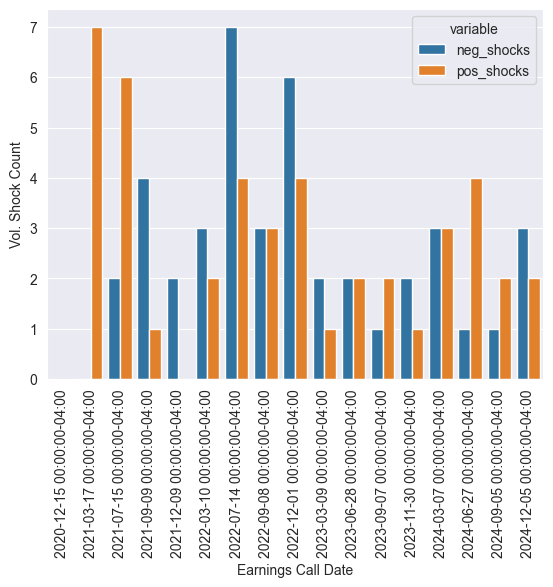

In [61]:
df_shocks = df_earnings[["Earnings Call Date", "neg_shocks", "pos_shocks", "Notes"]].melt(value_vars=["neg_shocks", "pos_shocks"], id_vars=["Earnings Call Date", "Notes"])
sns.barplot(df_shocks, x="Earnings Call Date", y="value", hue="variable")
plt.xlabel("Earnings Call Date")
plt.ylabel("Vol. Shock Count")
plt.xticks(rotation=90)

Text(0, 0.5, 'Vol. Shock Count')

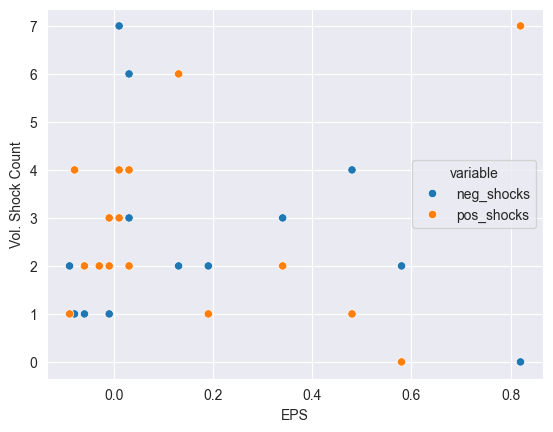

In [62]:
max_abs = df_shocks['value'].abs().max()
df_shocks['value_scaled'] = df_shocks['value'] / max_abs

sns.scatterplot(df_shocks, x="Notes", y="value", hue="variable")
plt.xlabel("EPS")
plt.ylabel("Vol. Shock Count")

In [68]:
# get the log return of each earnings date
# AOUT = AOUT.reset_index()
AOUT['Day'] = AOUT["Date"].dt.date
df_earnings['Day'] = df_earnings["Earnings Call Date"].dt.date
# df_earnings["Earnings Call Date"] = pd.to_datetime(df_earnings["Earnings Call Date"])
df_earningsII = df_earnings.merge(AOUT[["Day", "log_returns"]], left_on="Day", right_on="Day", how="left")
df_earningsII

,Quarter,Earnings Call Date,Time (ET),Notes,Regime,neg_shocks,pos_shocks,Day,log_returns
0,Q2 FY2021,2020-12-15 00:00:00-04:00,After Market Close,0.77,NaN,NaN,NaN,2020-12-15,0.118494
1,Q3 FY2021,2021-03-17 00:00:00-04:00,After Market Close,0.82,0.495094,0.0,7.0,2021-03-17,0.029722
2,Q4 FY2021,2021-07-15 00:00:00-04:00,After Market Close,0.13,0.494806,2.0,6.0,2021-07-15,0.058158
3,Q1 FY2022,2021-09-09 00:00:00-04:00,After Market Close,0.48,0.490779,4.0,1.0,2021-09-09,0.036099
4,Q2 FY2022,2021-12-09 00:00:00-04:00,After Market Close,0.58,0.486660,2.0,0.0,2021-12-09,-0.028607
5,Q3 FY2022,2022-03-10 00:00:00-04:00,After Market Close,0.03,0.489118,3.0,2.0,2022-03-10,-0.014203
6,Q4 FY2022,2022-07-14 00:00:00-04:00,After Market Close,0.01,0.485820,7.0,4.0,2022-07-14,0.016052
7,Q1 FY2023,2022-09-08 00:00:00-04:00,After Market Close,0.01,0.493793,3.0,3.0,2022-09-08,0.001185
8,Q2 FY2023,2022-12-01 00:00:00-04:00,After Market Close,0.03,0.501458,6.0,4.0,2022-12-01,0.009469
9,Q3 FY2023,2023-03-09 00:00:00-04:00,After Market Close,-0.09,0.488038,2.0,1.0,2023-03-09,0.009794


In [67]:
AOUT[(AOUT["Date"] >= "2023-11-30 00:00:00-04:00") & (AOUT["Date"] < "2023-12-01 00:00:00-04:00")]

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,Adj Close,log_returns,log_returns2,Regime,vol_schock,vol_schock_neg
824,2023-11-30 00:00:00-05:00,8.41,8.71,8.35,8.59,64600.0,0.0,0.0,AOUT,NaN,0.017616,0.017616,1,0,0
